In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv(
    "/content/healthcare_feature_engineered.csv"
)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (54966, 36)


,patient_id,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,age_group,admission_year,admission_month,admission_day,admission_quarter,length_of_stay,length_of_stay_category,age_band,admission_month_number,admission_season,admission_day_type,billing_category,billable_days,billing_per_day,insurance_type,long_stay_flag,high_billing_flag,analytical_risk_segment,patient_outcome_label,stay_cost_intensity
0,1,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,Young Adult,2024,January,Wednesday,Q1,2,Short Stay,19-30,1,Winter,Weekday,Medium,2,9428.14,Private,No,No,Review Recommended,Routine Monitoring,Above Median
1,2,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Senior,2019,August,Tuesday,Q3,6,Medium Stay,61-75,8,Monsoon,Weekday,High,6,5607.22,Government,No,No,Standard,Further Evaluation,Above Median
2,3,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,Elderly,2022,September,Thursday,Q3,15,Extended Stay,76+,9,Monsoon,Weekday,High,15,1863.67,Private,Yes,No,Review Recommended,Routine Monitoring,Above Median
3,4,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,Young Adult,2020,November,Wednesday,Q4,30,Extended Stay,19-30,11,Autumn,Weekday,Very High,30,1263.66,Government,Yes,Yes,Review Recommended,Review Recommended,Below Median
4,5,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,Adult,2022,September,Monday,Q3,20,Extended Stay,31-45,9,Monsoon,Weekday,Medium,20,711.92,Private,Yes,No,Review Recommended,Review Recommended,Below Median


In [5]:
df["date_of_admission"] = pd.to_datetime(
    df["date_of_admission"],
    errors="coerce"
)

df["discharge_date"] = pd.to_datetime(
    df["discharge_date"],
    errors="coerce"
)

In [6]:
df["date_of_admission"] = pd.to_datetime(
    df["date_of_admission"],
    errors="coerce"
)

df["discharge_date"] = pd.to_datetime(
    df["discharge_date"],
    errors="coerce"
)

In [7]:
# Create main KPIs
total_patients = df["patient_id"].nunique()
total_billing = df["billing_amount"].sum()
average_billing = df["billing_amount"].mean()
average_length_of_stay = df["length_of_stay"].mean()
average_billing_per_day = df["billing_per_day"].mean()
high_risk_patients = (
    df["analytical_risk_segment"] == "Higher Priority"
).sum()

print("Total Patients:", total_patients)
print("Total Billing:", round(total_billing, 2))
print("Average Billing:", round(average_billing, 2))
print(
    "Average Length of Stay:",
    round(average_length_of_stay, 2)
)
print(
    "Average Billing Per Day:",
    round(average_billing_per_day, 2)
)
print(
    "Higher Priority Patients:",
    high_risk_patients
)

Total Patients: 54966
Total Billing: 1406834551.85
Average Billing: 25594.63
Average Length of Stay: 15.5
Average Billing Per Day: 3398.45
Higher Priority Patients: 5671


In [8]:
# Patient distribution by gender
gender_counts = df["gender"].value_counts()

gender_counts

,count
gender,
Male,27496
Female,27470


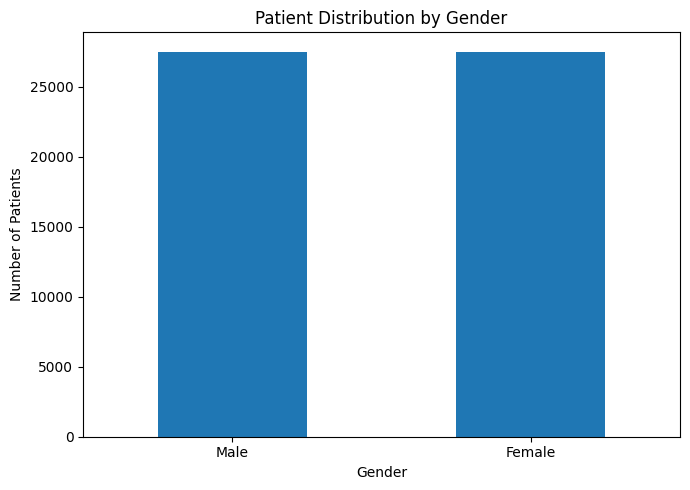

In [9]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind="bar")

plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
# Patient distribution by age group
age_group_counts = (
    df["age_group"]
    .value_counts()
)

age_group_counts



,count
age_group,
Elderly,16096
Young Adult,13519
Senior,12298
Adult,12167
Child,886


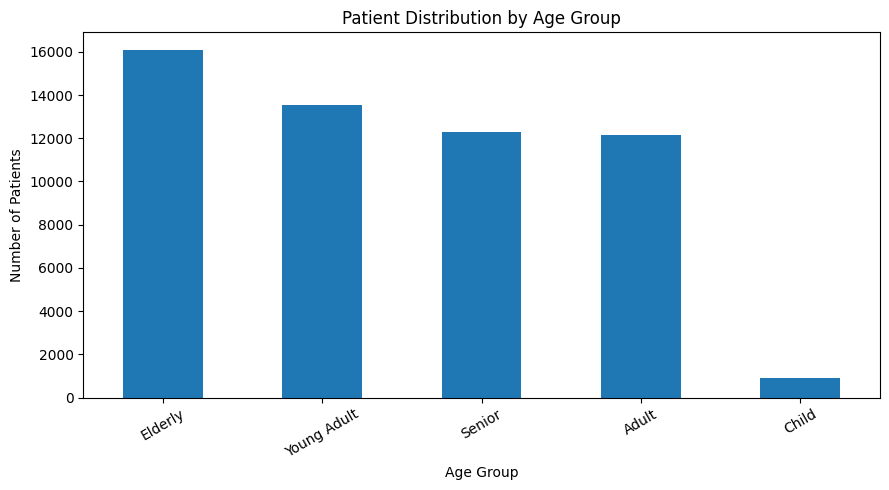

In [12]:
plt.figure(figsize=(9, 5))

age_group_counts.plot(kind="bar")

plt.title("Patient Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
# Medical condition distribution
condition_counts = (
    df["medical_condition"]
    .value_counts()
)

condition_counts

,count
medical_condition,
Arthritis,9218
Diabetes,9216
Hypertension,9151
Obesity,9146
Cancer,9140
Asthma,9095


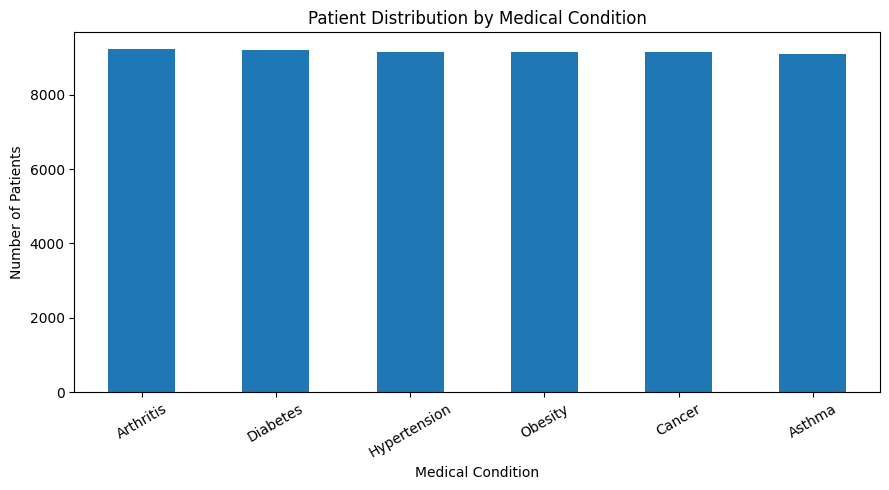

In [14]:
plt.figure(figsize=(9, 5))

condition_counts.plot(kind="bar")

plt.title("Patient Distribution by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [15]:
# Admission type analysis
admission_type_counts = (
    df["admission_type"]
    .value_counts()
)

admission_type_counts

,count
admission_type,
Elective,18473
Urgent,18391
Emergency,18102


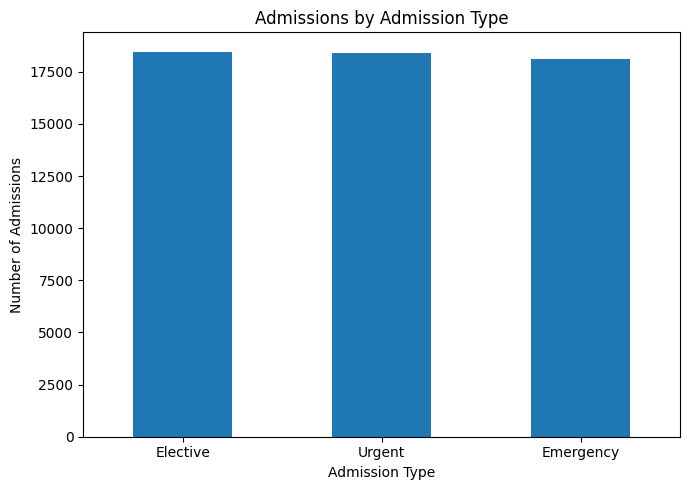

In [16]:
plt.figure(figsize=(7, 5))

admission_type_counts.plot(kind="bar")

plt.title("Admissions by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# Test-result distribution
test_result_counts = (
    df["test_results"]
    .value_counts()
)

test_result_counts

,count
test_results,
Abnormal,18437
Normal,18331
Inconclusive,18198


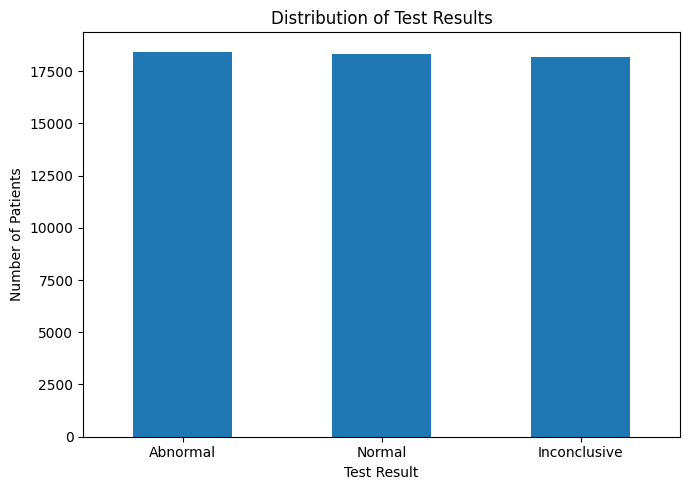

In [18]:
plt.figure(figsize=(7, 5))

test_result_counts.plot(kind="bar")

plt.title("Distribution of Test Results")
plt.xlabel("Test Result")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
# Total billing by medical condition
billing_by_condition = (
    df.groupby("medical_condition")["billing_amount"]
    .sum()
    .sort_values(ascending=False)
)

billing_by_condition

,billing_amount
medical_condition,
Diabetes,2.369809e+08
Obesity,2.365033e+08
Arthritis,2.354550e+08
Hypertension,2.338988e+08
Asthma,2.336069e+08
Cancer,2.303895e+08


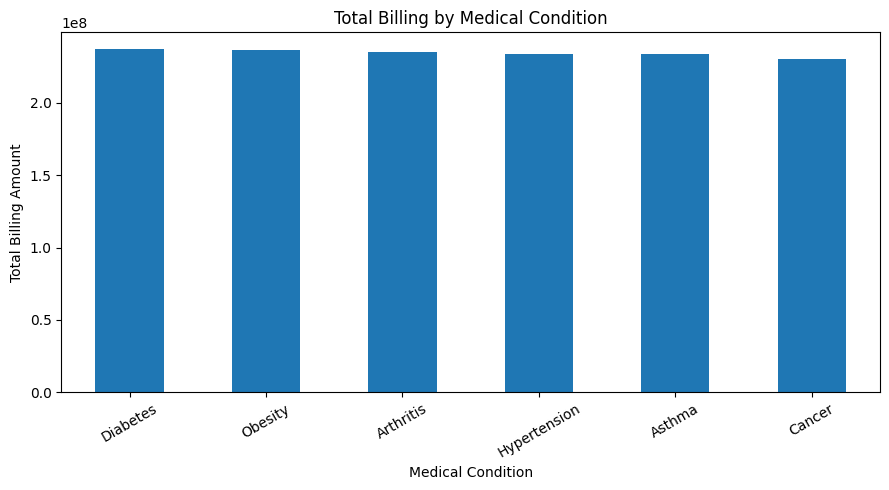

In [20]:
plt.figure(figsize=(9, 5))

billing_by_condition.plot(kind="bar")

plt.title("Total Billing by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Total Billing Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [21]:
# Average billing by medical condition
average_billing_by_condition = (
    df.groupby("medical_condition")["billing_amount"]
    .mean()
    .sort_values(ascending=False)
)

average_billing_by_condition

,billing_amount
medical_condition,
Obesity,25858.664148
Diabetes,25714.078018
Asthma,25685.203907
Hypertension,25559.919238
Arthritis,25542.959185
Cancer,25206.730665


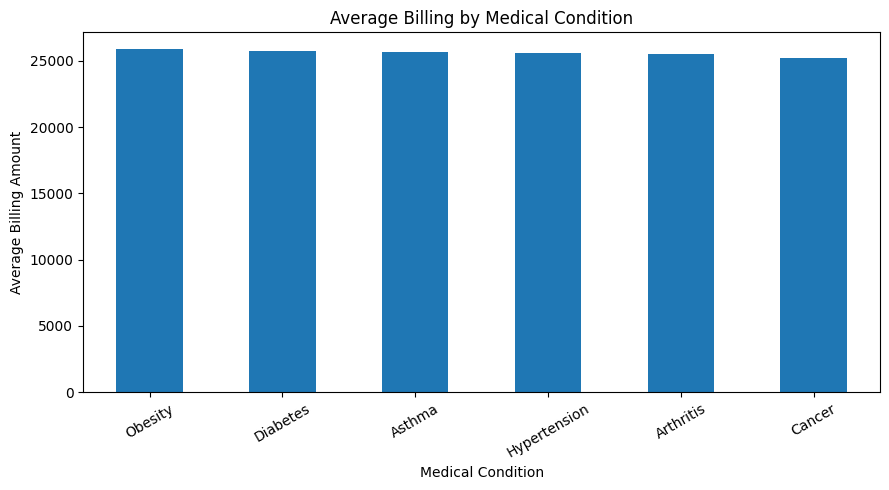

In [22]:
plt.figure(figsize=(9, 5))

average_billing_by_condition.plot(kind="bar")

plt.title("Average Billing by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Average Billing Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [23]:
# Billing by insurance provider
billing_by_insurance = (
    df.groupby("insurance_provider")["billing_amount"]
    .sum()
    .sort_values(ascending=False)
)

billing_by_insurance

,billing_amount
insurance_provider,
Cigna,2.849607e+08
Medicare,2.834586e+08
Blue Cross,2.808006e+08
UnitedHealthcare,2.804068e+08
Aetna,2.772078e+08


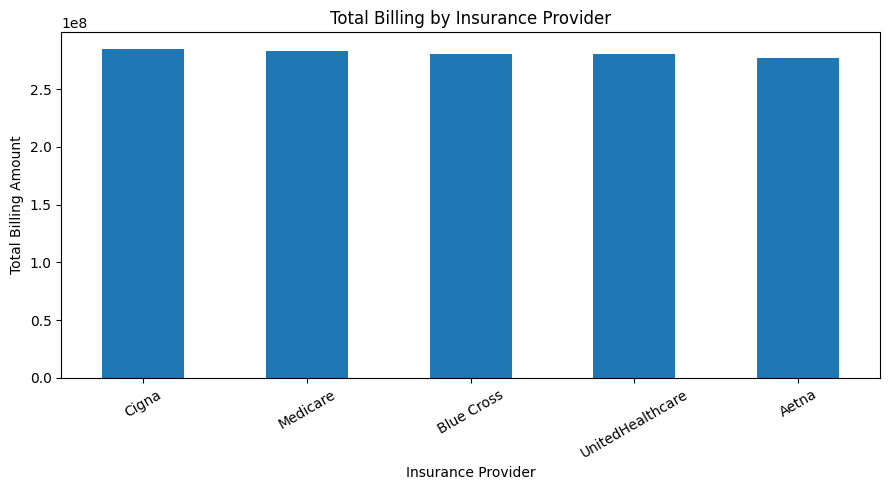

In [24]:
plt.figure(figsize=(9, 5))

billing_by_insurance.plot(kind="bar")

plt.title("Total Billing by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Total Billing Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [25]:
# Average billing by admission type
billing_by_admission_type = (
    df.groupby("admission_type")["billing_amount"]
    .mean()
    .sort_values(ascending=False)
)

billing_by_admission_type

,billing_amount
admission_type,
Elective,25663.206880
Urgent,25568.492204
Emergency,25551.209316


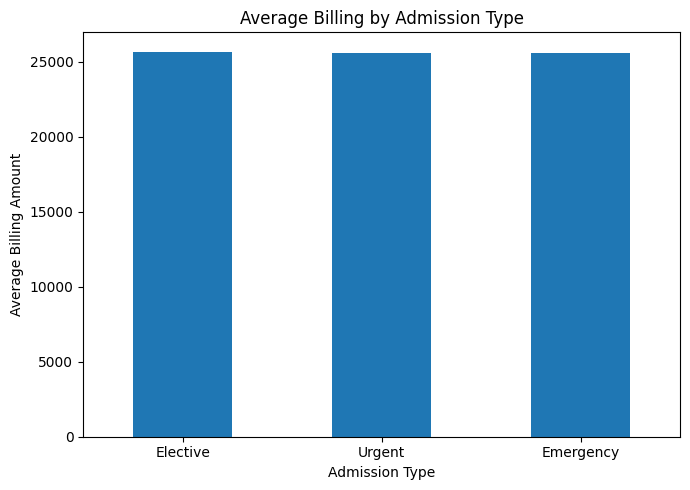

In [26]:
plt.figure(figsize=(7, 5))

billing_by_admission_type.plot(kind="bar")

plt.title("Average Billing by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Billing Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
# Average length of stay by medical condition
los_by_condition = (
    df.groupby("medical_condition")["length_of_stay"]
    .mean()
    .sort_values(ascending=False)
)

los_by_condition

,length_of_stay
medical_condition,
Asthma,15.677295
Arthritis,15.504231
Cancer,15.501204
Obesity,15.447627
Hypertension,15.436236
Diabetes,15.430664


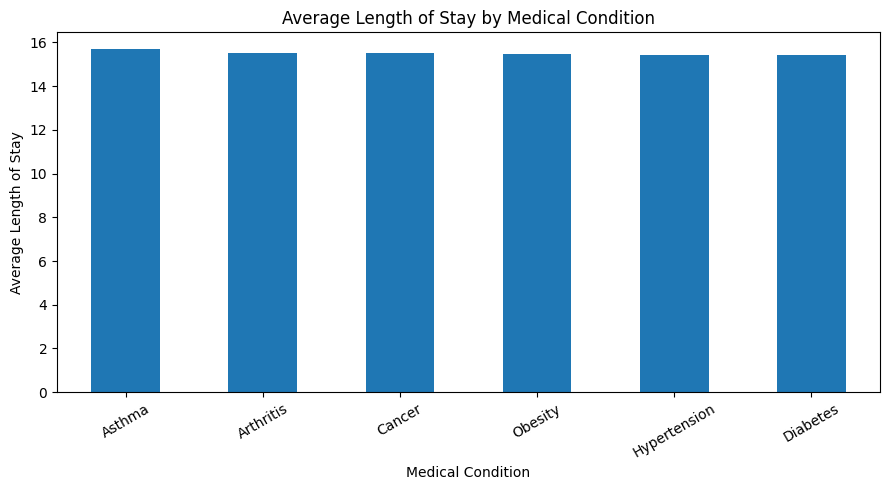

In [28]:
plt.figure(figsize=(9, 5))

los_by_condition.plot(kind="bar")

plt.title("Average Length of Stay by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Average Length of Stay")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [29]:
# Length-of-stay category distribution
stay_category_counts = (
    df["length_of_stay_category"]
    .value_counts()
)

stay_category_counts

,count
length_of_stay_category,
Extended Stay,29201
Long Stay,12879
Medium Stay,7420
Short Stay,5466


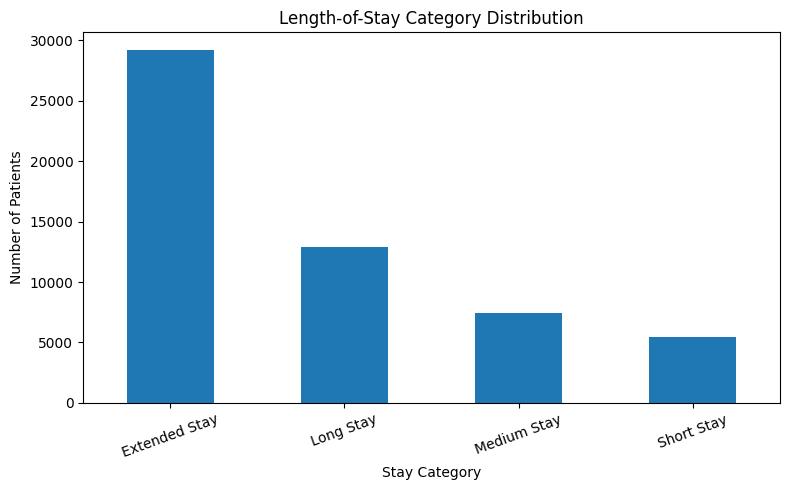

In [30]:
plt.figure(figsize=(8, 5))

stay_category_counts.plot(kind="bar")

plt.title("Length-of-Stay Category Distribution")
plt.xlabel("Stay Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [31]:
# Yearly admission trend
yearly_admissions = (
    df.groupby("admission_year")
    .size()
)

yearly_admissions

,0
admission_year,
2019,7300
2020,11172
2021,10816
2022,10915
2023,10936
2024,3827


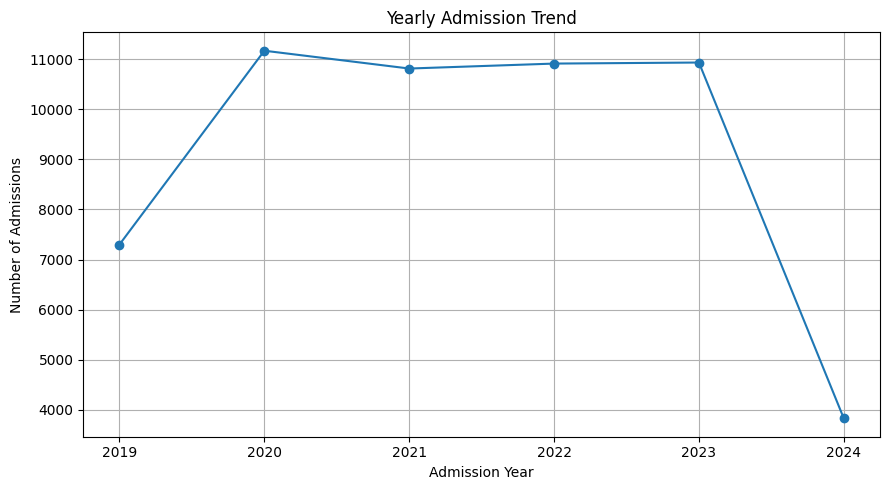

In [32]:
plt.figure(figsize=(9, 5))

yearly_admissions.plot(
    kind="line",
    marker="o"
)

plt.title("Yearly Admission Trend")
plt.xlabel("Admission Year")
plt.ylabel("Number of Admissions")
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
# Monthly admission pattern
monthly_admissions = (
    df.groupby(
        [
            "admission_month_number",
            "admission_month"
        ]
    )
    .size()
    .reset_index(name="admissions")
    .sort_values("admission_month_number")
)

monthly_admissions

,admission_month_number,admission_month,admissions
0,1,January,4655
1,2,February,4210
2,3,March,4622
3,4,April,4478
4,5,May,4555
5,6,June,4650
6,7,July,4765
7,8,August,4785
8,9,September,4508
9,10,October,4613


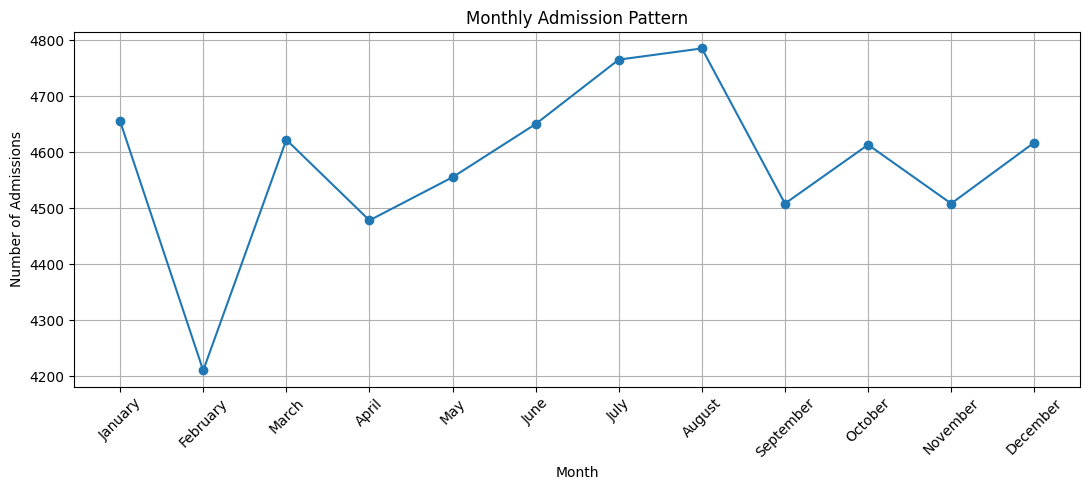

In [34]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_admissions["admission_month"],
    monthly_admissions["admissions"],
    marker="o"
)

plt.title("Monthly Admission Pattern")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# Weekday versus weekend admissions
day_type_counts = (
    df["admission_day_type"]
    .value_counts()
)

day_type_counts

,count
admission_day_type,
Weekday,39294
Weekend,15672


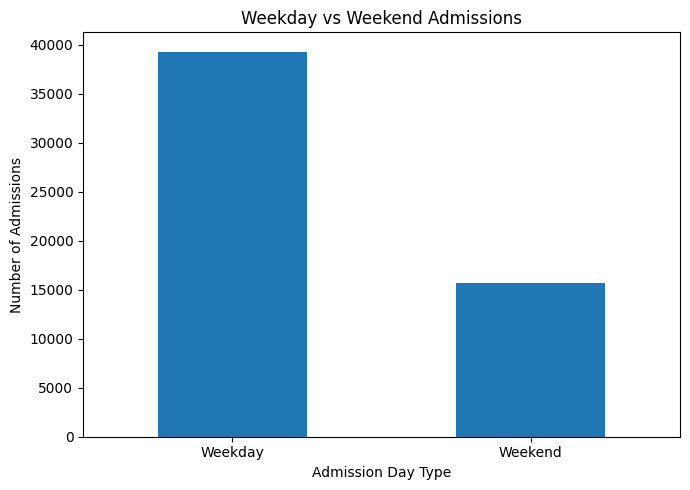

In [36]:
plt.figure(figsize=(7, 5))

day_type_counts.plot(kind="bar")

plt.title("Weekday vs Weekend Admissions")
plt.xlabel("Admission Day Type")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
# Admission season analysis
season_counts = (
    df["admission_season"]
    .value_counts()
)

season_counts

,count
admission_season,
Monsoon,18708
Summer,13655
Winter,13482
Autumn,9121


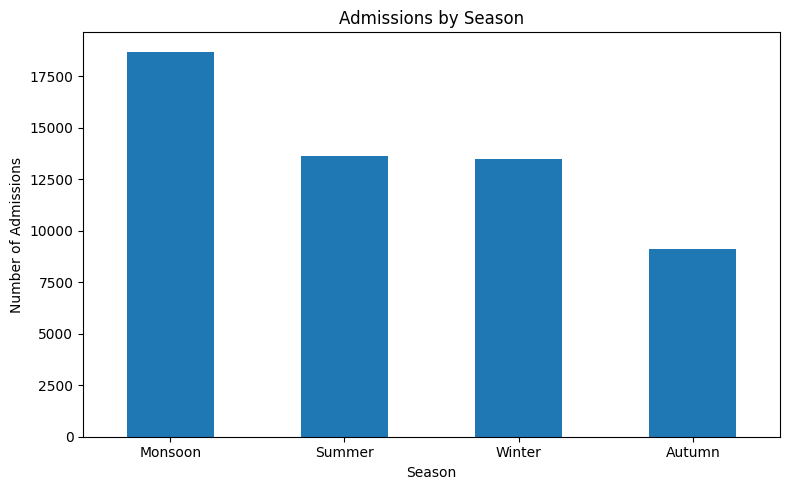

In [38]:
plt.figure(figsize=(8, 5))

season_counts.plot(kind="bar")

plt.title("Admissions by Season")
plt.xlabel("Season")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [39]:
# Medication usage
medication_counts = (
    df["medication"]
    .value_counts()
)

medication_counts

,count
medication,
Lipitor,11038
Ibuprofen,11023
Aspirin,10984
Paracetamol,10965
Penicillin,10956


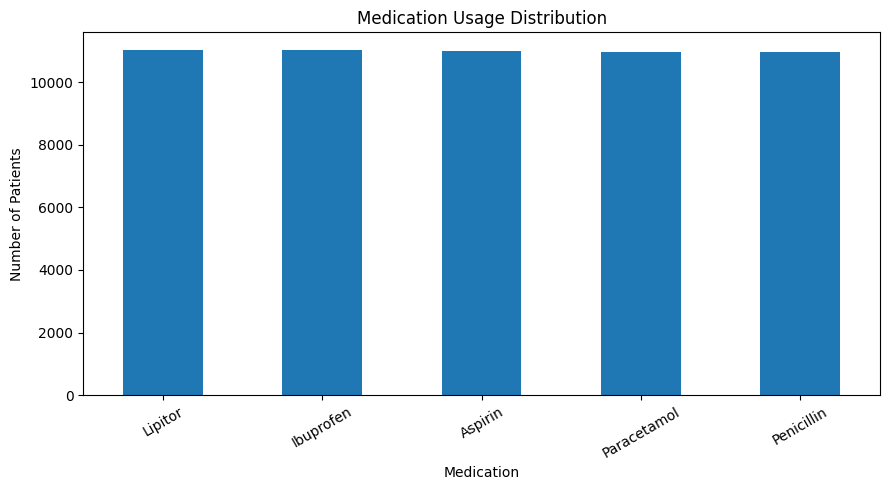

In [40]:
plt.figure(figsize=(9, 5))

medication_counts.plot(kind="bar")

plt.title("Medication Usage Distribution")
plt.xlabel("Medication")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [41]:
# Risk segment distribution
risk_counts = (
    df["analytical_risk_segment"]
    .value_counts()
)

risk_counts

,count
analytical_risk_segment,
Review Recommended,32468
Standard,16827
Higher Priority,5671


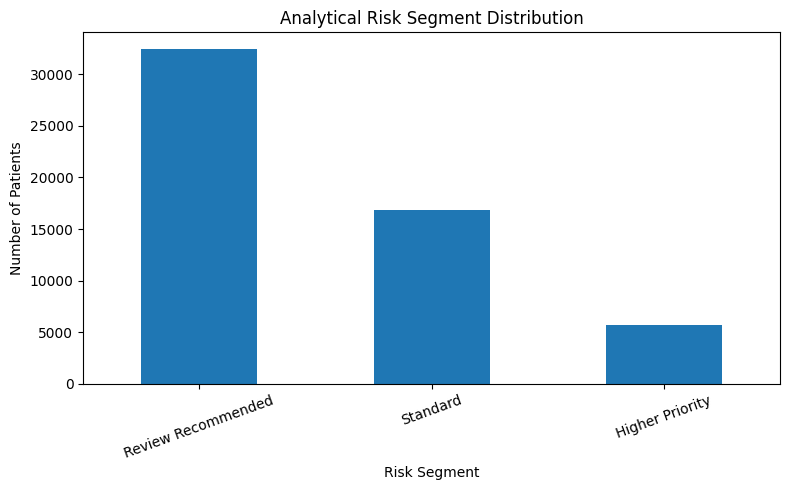

In [42]:
plt.figure(figsize=(8, 5))

risk_counts.plot(kind="bar")

plt.title("Analytical Risk Segment Distribution")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [43]:
# Billing category distribution
billing_category_counts = (
    df["billing_category"]
    .value_counts()
)

billing_category_counts

,count
billing_category,
Medium,13794
Very High,13742
Low,13742
High,13688


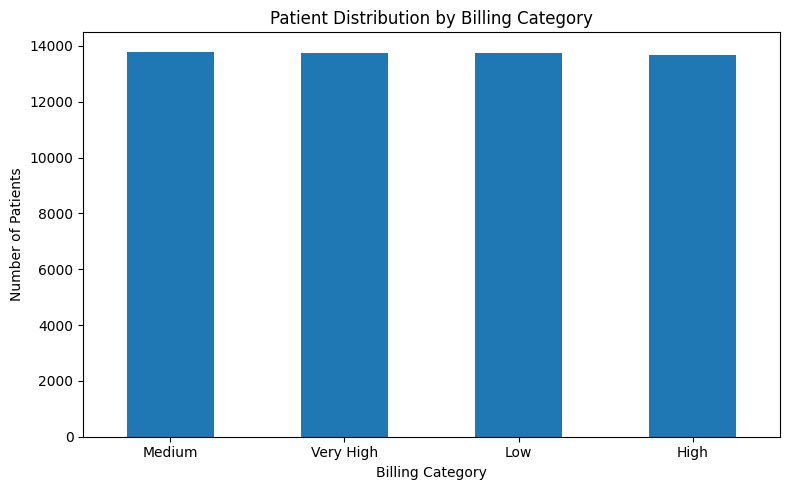

In [44]:
plt.figure(figsize=(8, 5))

billing_category_counts.plot(kind="bar")

plt.title("Patient Distribution by Billing Category")
plt.xlabel("Billing Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

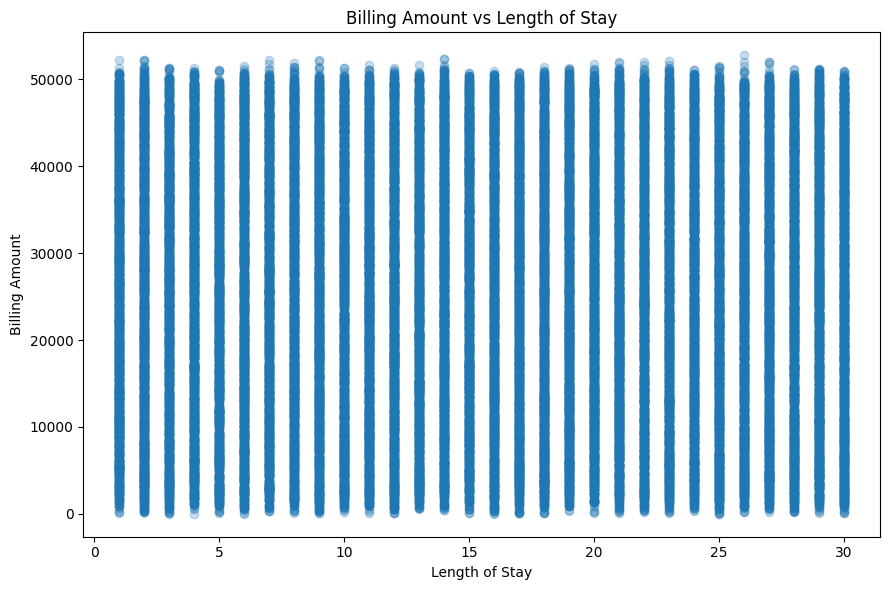

In [45]:
# Billing and length-of-stay relationship
plt.figure(figsize=(9, 6))

plt.scatter(
    df["length_of_stay"],
    df["billing_amount"],
    alpha=0.25
)

plt.title("Billing Amount vs Length of Stay")
plt.xlabel("Length of Stay")
plt.ylabel("Billing Amount")
plt.tight_layout()
plt.show()

In [46]:
billing_los_correlation = (
    df["billing_amount"]
    .corr(df["length_of_stay"])
)

print(
    "Correlation between billing and length of stay:",
    round(billing_los_correlation, 4)
)

Correlation between billing and length of stay: -0.0048


In [47]:
# Test results by medical condition
condition_test_results = pd.crosstab(
    df["medical_condition"],
    df["test_results"]
)

condition_test_results

test_results,Abnormal,Inconclusive,Normal
medical_condition,,,
Arthritis,3156,3062,3000
Asthma,2980,2999,3116
Cancer,3089,3033,3018
Diabetes,3131,3024,3061
Hypertension,2977,3068,3106
Obesity,3104,3012,3030


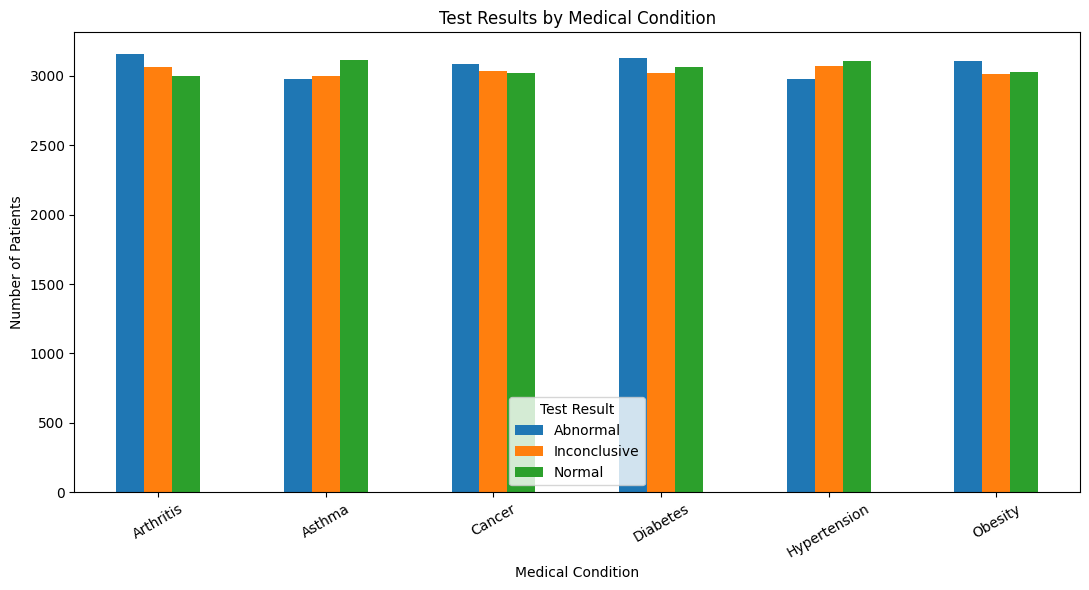

In [48]:
condition_test_results.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Test Results by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.legend(title="Test Result")
plt.tight_layout()
plt.show()

In [50]:
# Admission type and test results
admission_test_results = pd.crosstab(
    df["admission_type"],
    df["test_results"]
)

admission_test_results

test_results,Abnormal,Inconclusive,Normal
admission_type,,,
Elective,6232,6054,6187
Emergency,6038,6020,6044
Urgent,6167,6124,6100


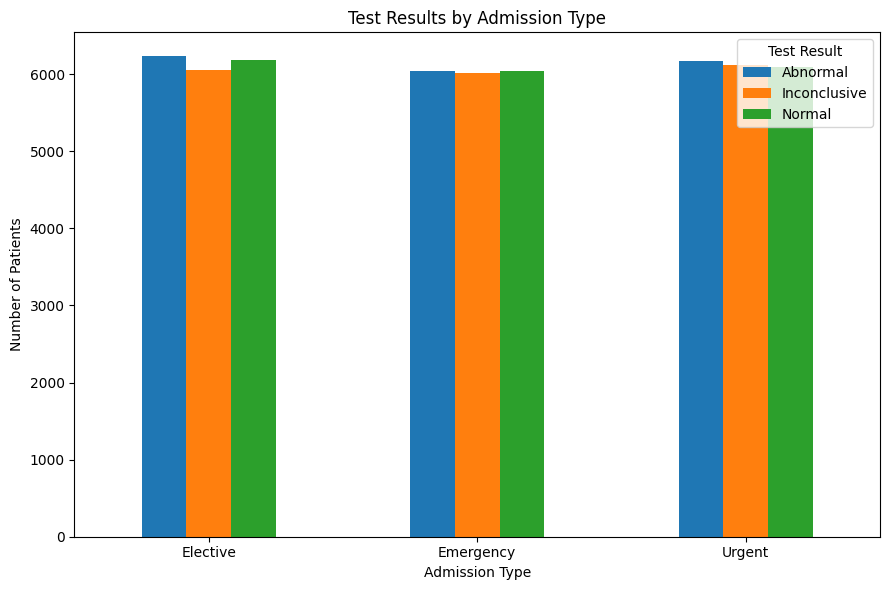

In [51]:
admission_test_results.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Test Results by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(title="Test Result")
plt.tight_layout()
plt.show()

In [52]:
# Average billing per day by condition
billing_per_day_condition = (
    df.groupby("medical_condition")["billing_per_day"]
    .mean()
    .sort_values(ascending=False)
)

billing_per_day_condition

,billing_per_day
medical_condition,
Obesity,3457.266385
Hypertension,3425.640953
Arthritis,3414.086718
Diabetes,3400.883576
Asthma,3385.474032
Cancer,3307.031190


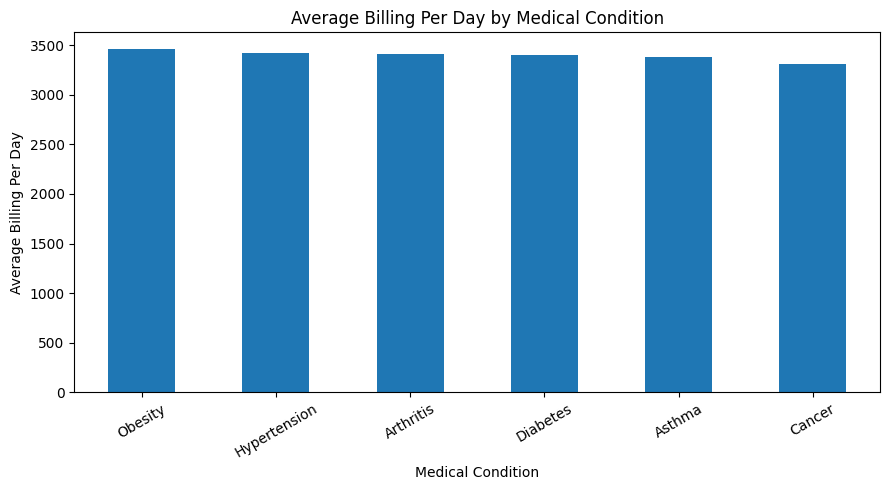

In [53]:
plt.figure(figsize=(9, 5))

billing_per_day_condition.plot(kind="bar")

plt.title("Average Billing Per Day by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Average Billing Per Day")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [54]:
# Create KPI summary table
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Patients",
        "Total Billing",
        "Average Billing",
        "Average Length of Stay",
        "Average Billing Per Day",
        "Higher Priority Patients",
        "Long-Stay Patients",
        "High-Billing Patients"
    ],
    "Value": [
        total_patients,
        round(total_billing, 2),
        round(average_billing, 2),
        round(average_length_of_stay, 2),
        round(average_billing_per_day, 2),
        high_risk_patients,
        (df["long_stay_flag"] == "Yes").sum(),
        (df["high_billing_flag"] == "Yes").sum()
    ]
})

kpi_summary

,KPI,Value
0,Total Patients,5.496600e+04
1,Total Billing,1.406835e+09
2,Average Billing,2.559463e+04
3,Average Length of Stay,1.550000e+01
4,Average Billing Per Day,3.398450e+03
5,Higher Priority Patients,5.671000e+03
6,Long-Stay Patients,4.208000e+04
7,High-Billing Patients,1.374200e+04


In [55]:
kpi_summary.to_csv(
    "/content/healthcare_kpi_summary.csv",
    index=False
)

In [56]:
# Create grouped analysis report
condition_summary = (
    df.groupby("medical_condition")
    .agg(
        total_patients=("patient_id", "count"),
        total_billing=("billing_amount", "sum"),
        average_billing=("billing_amount", "mean"),
        average_length_of_stay=("length_of_stay", "mean"),
        average_billing_per_day=("billing_per_day", "mean")
    )
    .reset_index()
)

condition_summary[
    [
        "total_billing",
        "average_billing",
        "average_length_of_stay",
        "average_billing_per_day"
    ]
] = condition_summary[
    [
        "total_billing",
        "average_billing",
        "average_length_of_stay",
        "average_billing_per_day"
    ]
].round(2)

condition_summary

,medical_condition,total_patients,total_billing,average_billing,average_length_of_stay,average_billing_per_day
0,Arthritis,9218,2.354550e+08,25542.96,15.50,3414.09
1,Asthma,9095,2.336069e+08,25685.20,15.68,3385.47
2,Cancer,9140,2.303895e+08,25206.73,15.50,3307.03
3,Diabetes,9216,2.369809e+08,25714.08,15.43,3400.88
4,Hypertension,9151,2.338988e+08,25559.92,15.44,3425.64
5,Obesity,9146,2.365033e+08,25858.66,15.45,3457.27


In [57]:
condition_summary.to_csv(
    "/content/medical_condition_summary.csv",
    index=False
)

In [58]:
# Generate an automated insight summary
highest_patient_condition = condition_counts.idxmax()
highest_billing_condition = billing_by_condition.idxmax()
highest_average_billing_condition = (
    average_billing_by_condition.idxmax()
)
longest_stay_condition = los_by_condition.idxmax()
highest_insurance_billing = billing_by_insurance.idxmax()
most_common_admission_type = admission_type_counts.idxmax()
most_common_test_result = test_result_counts.idxmax()

print("Key Business Insights")
print("---------------------")

print(
    f"1. {highest_patient_condition} has the highest "
    "number of patient records."
)

print(
    f"2. {highest_billing_condition} generates the "
    "highest total billing."
)

print(
    f"3. {highest_average_billing_condition} has the "
    "highest average billing."
)

print(
    f"4. {longest_stay_condition} has the highest "
    "average length of stay."
)

print(
    f"5. {highest_insurance_billing} contributes the "
    "highest total billing."
)

print(
    f"6. {most_common_admission_type} is the most "
    "common admission type."
)

print(
    f"7. {most_common_test_result} is the most "
    "common test-result category."
)

Key Business Insights
---------------------
1. Arthritis has the highest number of patient records.
2. Diabetes generates the highest total billing.
3. Obesity has the highest average billing.
4. Asthma has the highest average length of stay.
5. Cigna contributes the highest total billing.
6. Elective is the most common admission type.
7. Abnormal is the most common test-result category.


In [59]:
# Save the insight report
insight_report = pd.DataFrame({
    "Insight": [
        "Most common medical condition",
        "Highest total billing condition",
        "Highest average billing condition",
        "Longest average stay condition",
        "Highest billing insurance provider",
        "Most common admission type",
        "Most common test result",
        "Billing and LOS correlation"
    ],
    "Result": [
        highest_patient_condition,
        highest_billing_condition,
        highest_average_billing_condition,
        longest_stay_condition,
        highest_insurance_billing,
        most_common_admission_type,
        most_common_test_result,
        round(billing_los_correlation, 4)
    ]
})

insight_report

,Insight,Result
0,Most common medical condition,Arthritis
1,Highest total billing condition,Diabetes
2,Highest average billing condition,Obesity
3,Longest average stay condition,Asthma
4,Highest billing insurance provider,Cigna
5,Most common admission type,Elective
6,Most common test result,Abnormal
7,Billing and LOS correlation,-0.0048


In [60]:
insight_report.to_csv(
    "/content/eda_insight_report.csv",
    index=False
)